# Assignment

Building on the Boolean Networks practical, you will conduct an independent analysis of cancer-causing mutations using Boolean networks.

Use the completed BooleanModeling.ipynb notebook from the practical as a starting point.

Create 4 different mutated versions of the cell regulatory network by modifying the Boolean rules:

- Mutation A: p53 Knockout (Loss of tumor suppressor): network.add_rule('p53', lambda s: False, "p53 = BROKEN (always OFF)")
- Mutation B: MYC Amplification (Oncogene overexpression): network.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")
- Mutation C: MDM2 Overexpression (p53 pathway disruption): network.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")
- Mutation D: Your Choice (Design your own mutation)

For each mutation (A, B, C, D) + normal network:

- Scenario Analysis: Test all 3 scenarios from practical
- Attractor Analysis: Find all attractors for each mutated network (What percentage of states lead to cancer-like states?)

Answer the following questions in your README.md file:

- Which mutation is most dangerous and why? Provide quantitative evidence.
- Explain the role of feedback loops (e.g., MYC → MDM2 → p53)
- What are the limitations of this Boolean network model? Discuss 3 specific limitations.


## Setup


In [1]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# 🟢 Helper class to build and simulate boolean network

class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)

## Normal Network (blocks copied from practical)


In [3]:
# 🟢 Create the regulatory network
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
network = BooleanNetwork(nodes)

# Define Boolean rules (based on real biology, simplified)
network.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
network.add_rule('p21', lambda s: s['p53'], "p21 = p53")
network.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
network.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
network.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
network.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
network.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


In [4]:
# Run the 3 scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

node_names = sorted(network.nodes.keys())

# run each scenario
for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[s] = trajectory

    final_state = trajectory[-1]
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}
    print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
   Stressed Cell: Final state: Growth=0, Death=1, p53=1
   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


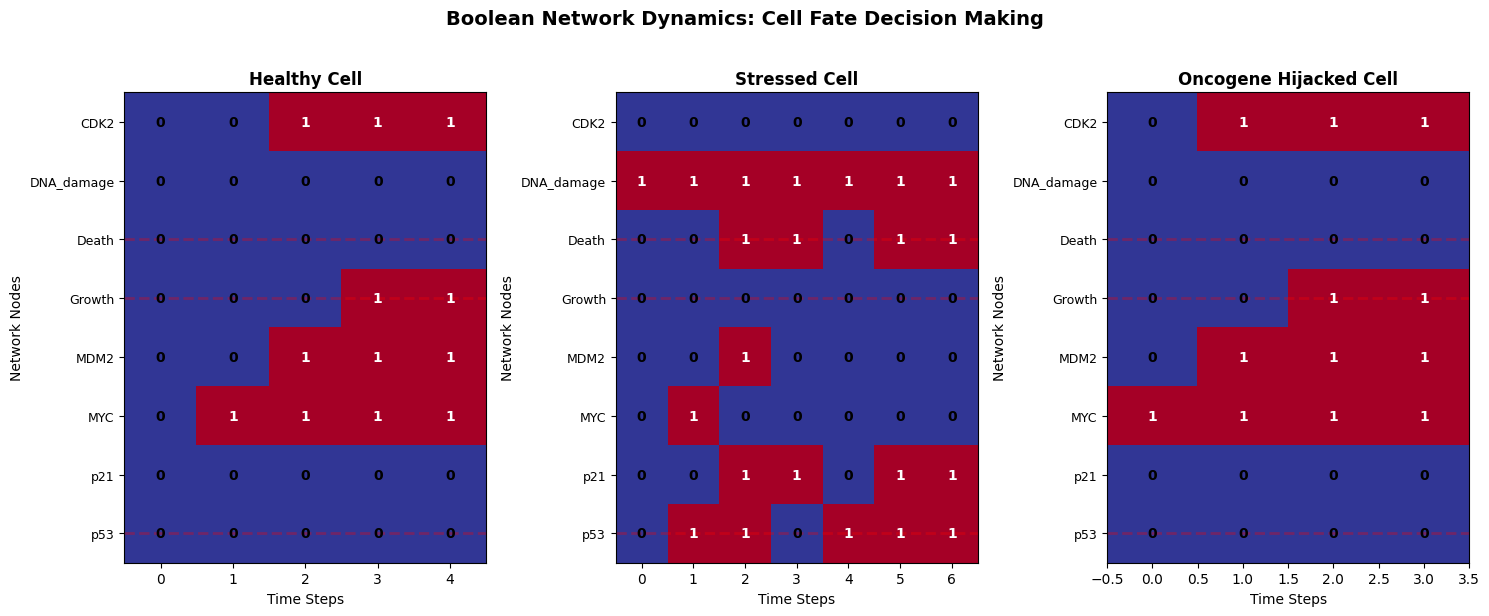

In [5]:
# 🟢 Visualize results
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# 🟡 Let's find the attractor states

attractors = []
max_steps=15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2**n_nodes} possible initial states...")

# all possible starting states
all_states = list(product([0, 1], repeat=n_nodes))

for initial_state in all_states:
  # Set the network to this initial state
  state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**state_dict)

  # simulate
  trajectory = network.simulate(steps=max_steps, record_history=True)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:
    final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

  # Check if this is a new attractor
    if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
      if final_state not in attractors:
        attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reac


FOUND 3 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → Normal growth

Attractor 2: [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
   Growth: OFF
   Death: ON
   p53: ON
   DNA Damage: ON
   → Cell death

Attractor 3: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → Cancer-like (growing with DNA damage)


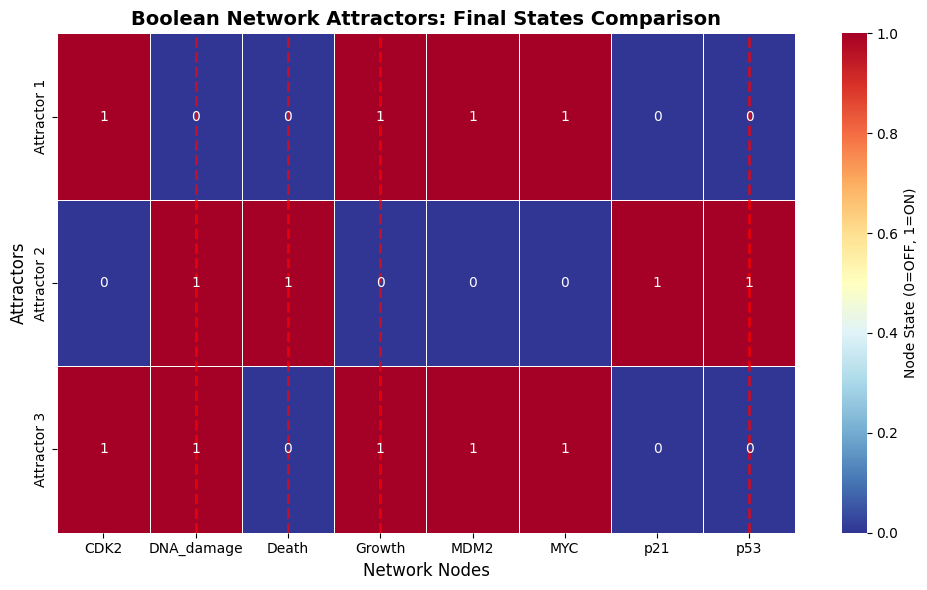

In [7]:
# 🟡 Let's find the attractor states

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
        print(f"\nAttractor {i+1}: {list(attractor)}")

        # Create state dictionary for easy access
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # Analyze the biological meaning
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1


        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        # interpret
        if growth_active and not death_active and not dna_damage_active:
            interpretation = "Normal growth"
        elif death_active and not growth_active:
            interpretation = "Cell death"
        elif growth_active and not death_active and dna_damage_active:
            interpretation = "Cancer-like (growing with DNA damage)"
        else:
            interpretation = "CONFLICT - Unusual state"

        print(f"   → {interpretation}")


# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i+1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx+0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady 

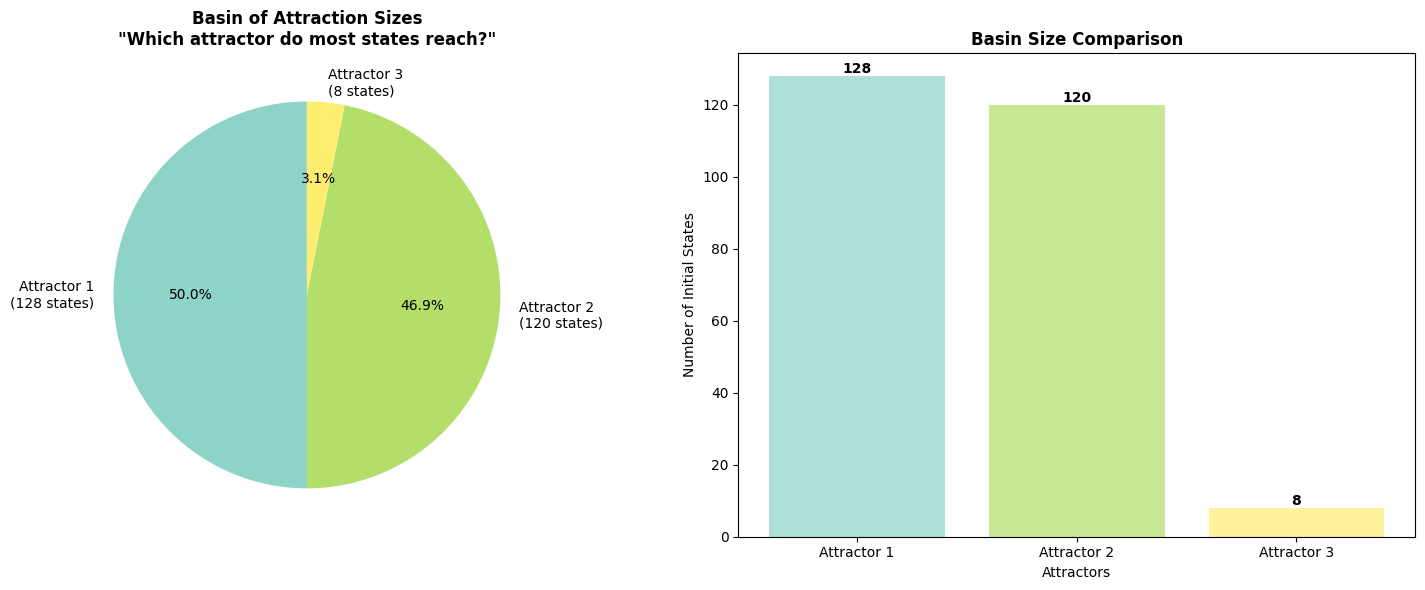

In [8]:
# 🟡 Which states end up in which attractor?

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Mutation A: p53 Knockout

Scenario Analysis: Test all 3 scenarios from practical

We switch p53 OFF and keep the other rules the same. Without p53, the cell may
keep growing even when its DNA is damaged.


In [9]:
from copy import deepcopy

mutation_a = deepcopy(network)
mutation_a.add_rule('p53', lambda s: False, "p53 = BROKEN (always OFF)")

rows = []
for name, initial in scenarios.items():
    mutation_a.set_state(**initial)
    mutation_a.simulate(steps=8)
    normal = dict(zip(node_names, results[name][-1]))
    rows.append([name, normal['Growth'], normal['Death'],
                 mutation_a.nodes['Growth'], mutation_a.nodes['Death']])

display(pd.DataFrame(rows, columns=['Scenario', 'Normal Growth', 'Normal Death',
                                   'Mutation A Growth', 'Mutation A Death']))

   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps


,Scenario,Normal Growth,Normal Death,Mutation A Growth,Mutation A Death
0,Healthy Cell,1,0,1,0
1,Stressed Cell,0,1,1,0
2,Oncogene Hijacked Cell,1,0,1,0


Attractor Analysis: Find all attractors for each mutated network (What percentage of states lead to cancer-like states?)

We test all starting states and stop each run when a state repeats. Cancer-like means DNA damage ON, Growth ON and Death OFF (throughout a cycle, if there is one).

Starting states with p53 ON are included; the mutation turns it OFF on the first update.


In [10]:
for name, original in [('Normal', network), ('Mutation A', mutation_a)]:
    model = deepcopy(original)
    basins = Counter()
    for initial in product([0, 1], repeat=len(node_names)):
        model.set_state(**dict(zip(node_names, initial)))
        model.history = []
        path = []
        state = tuple(model.get_state_vector())
        while state not in path:
            path.append(state)
            model.update_synchronous()
            state = tuple(model.get_state_vector())
        cycle = path[path.index(state):]
        # Sorting gives the same key whichever point of a cycle we enter.
        basins[tuple(sorted(cycle))] += 1

    rows = []
    cancer_count = 0
    for cycle, count in basins.items():
        states = [dict(zip(node_names, state)) for state in cycle]
        cancer = all(s['DNA_damage'] == 1 and s['Growth'] == 1
                     and s['Death'] == 0 for s in states)
        if cancer:
            cancer_count += count
        rows.append([cycle, len(cycle), count, 100 * count / 256, cancer])

    print(name, '- node order:', node_names)
    display(pd.DataFrame(rows, columns=['Attractor states', 'Period',
                                       'Starting states', 'Percent', 'Cancer-like']))
    print(f'Cancer-like: {cancer_count}/256 ({100 * cancer_count / 256:.3f}%)')

Normal - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.000,False
1,"((0, 1, 1, 0, 0, 0, 1, 1),)",1,120,46.875,False
2,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,8,3.125,True


Cancer-like: 8/256 (3.125%)
Mutation A - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.0,False
1,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,128,50.0,True


Cancer-like: 128/256 (50.000%)


Mutation A has two fixed attractors: growth with or without DNA damage.
The stressed cell keeps growing instead of switching on Death. The other two
scenarios end in growth without damage, just like the normal network.

Cancer-like outcomes rise from **8/256 (3.125%)** in the normal network to
**128/256 (50%)** with Mutation A. All damaged starting states now lead to growth.
Without p53, p21 turns OFF, allowing MYC and CDK2 to stay active.


## Mutation B: MYC Amplification


**Scenario analysis**


In [11]:
from copy import deepcopy

mutation_b = deepcopy(network)
mutation_b.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")

rows = []
for name, initial in scenarios.items():
    mutation_b.set_state(**initial)
    mutation_b.simulate(steps=8)
    normal = dict(zip(node_names, results[name][-1]))
    rows.append([name, normal['Growth'], normal['Death'],
                 mutation_b.nodes['Growth'], mutation_b.nodes['Death']])

display(pd.DataFrame(rows, columns=['Scenario', 'Normal Growth', 'Normal Death',
                                   'Mutation B Growth', 'Mutation B Death']))

   Reached steady state after 4 steps
   Reached steady state after 7 steps
   Reached steady state after 3 steps


,Scenario,Normal Growth,Normal Death,Mutation B Growth,Mutation B Death
0,Healthy Cell,1,0,1,0
1,Stressed Cell,0,1,1,0
2,Oncogene Hijacked Cell,1,0,1,0


_Interpretation_

With MYC mutation, any cell, whether it is healthy, stressed or cancerous cell, it will grow, compared to the normal case, where for stressed cell apoptosis occurs.


**Attractor analysis**


In [12]:
for name, original in [('Normal', network), ('Mutation B', mutation_b)]:
    model = deepcopy(original)
    basins = Counter()
    for initial in product([0, 1], repeat=len(node_names)):
        model.set_state(**dict(zip(node_names, initial)))
        model.history = []
        path = []
        state = tuple(model.get_state_vector())
        while state not in path:
            path.append(state)
            model.update_synchronous()
            state = tuple(model.get_state_vector())
        cycle = path[path.index(state):]
        # Sorting gives the same key whichever point of a cycle we enter.
        basins[tuple(sorted(cycle))] += 1

    rows = []
    cancer_count = 0
    for cycle, count in basins.items():
        states = [dict(zip(node_names, state)) for state in cycle]
        cancer = all(s['DNA_damage'] == 1 and s['Growth'] == 1
                     and s['Death'] == 0 for s in states)
        if cancer:
            cancer_count += count
        rows.append([cycle, len(cycle), count, 100 * count / 256, cancer])

    print(name, '- node order:', node_names)
    display(pd.DataFrame(rows, columns=['Attractor states', 'Period',
                                       'Starting states', 'Percent', 'Cancer-like']))
    print(f'Cancer-like: {cancer_count}/256 ({100 * cancer_count / 256:.3f}%)')

Normal - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.000,False
1,"((0, 1, 1, 0, 0, 0, 1, 1),)",1,120,46.875,False
2,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,8,3.125,True


Cancer-like: 8/256 (3.125%)
Mutation B - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.0,False
1,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,128,50.0,True


Cancer-like: 128/256 (50.000%)


_Interpretation_

For the MYC mutation, 50% of the starting states converge to cancer-like steady-states, compared to 3.125% in the normal case. Both steady states have unconstrained growth - Growth is 1, while Death is 0.


## Mutation C: MDM2 Overexpression


Scenario Analysis: test all 3 scenarios from practical

MDM2 is set to always ON. MDM2 blocks p53 so p53 should not be able to turn on anymore even with DNA damage.

In [13]:
# mutation c, mdm2 is always on
mutation_c = deepcopy(network)
mutation_c.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")

for name in scenarios:
    mutation_c.set_state(**scenarios[name])
    mutation_c.simulate(steps=8)
    print(name)
    print("   Growth =", mutation_c.nodes['Growth'])
    print("   Death =", mutation_c.nodes['Death'])
    print("   p53 =", mutation_c.nodes['p53'])

   Reached steady state after 4 steps
Healthy Cell
   Growth = 1
   Death = 0
   p53 = 0
   Reached steady state after 7 steps
Stressed Cell
   Growth = 1
   Death = 0
   p53 = 0
   Reached steady state after 3 steps
Oncogene Hijacked Cell
   Growth = 1
   Death = 0
   p53 = 0


Attractor Analysis: find all attractors for each mutated network (What percentage of states lead to cancer-like states?)

Same as the normal network, run all 256 starting states and see where they end up.

In [14]:
# find attractors for mutation c
attractors = []
counts = []

for start in all_states:
    state = {}
    for i in range(n_nodes):
        state[node_names[i]] = start[i]
    mutation_c.set_state(**state)
    mutation_c.history = []
    for step in range(max_steps):
        mutation_c.update_synchronous()

    # steady state if the last two states are the same
    if mutation_c.history[-1] == mutation_c.history[-2]:
        final = mutation_c.history[-1]
        if final in attractors:
            pos = attractors.index(final)
            counts[pos] = counts[pos] + 1
        else:
            attractors.append(final)
            counts.append(1)

print("found", len(attractors), "attractors")
print("node order:", node_names)

cancer = 0
for i in range(len(attractors)):
    print("attractor", i+1, ":", attractors[i], "-", counts[i], "states")
    growth = attractors[i][node_names.index('Growth')]
    damage = attractors[i][node_names.index('DNA_damage')]
    death = attractors[i][node_names.index('Death')]
    # cancer like = growing with dna damage and not dying
    if growth == 1 and damage == 1 and death == 0:
        print("   cancer-like")
        cancer = cancer + counts[i]

print("cancer-like states:", cancer, "out of 256")
print("percentage:", cancer / 256 * 100, "%")

found 2 attractors
node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']
attractor 1 : [1, 0, 0, 1, 1, 1, 0, 0] - 128 states
attractor 2 : [1, 1, 0, 1, 1, 1, 0, 0] - 128 states
   cancer-like
cancer-like states: 128 out of 256
percentage: 50.0 %


Mutation C only has 2 attractors, growing without damage and growing with damage. The death attractor is gone. As you can see above the stressed cell now keeps growing instead of dying, the other two scenarios are the same as normal. Cancer-like states go from 8/256 (3.125%) to 128/256 (50%), so every starting state with DNA damage ends up growing. This is the same result as Mutation A, because MDM2 is the only thing that turns p53 off in the rules, so keeping MDM2 on is the same as removing p53. The only difference is that p53 can turn on for one step at the start before MDM2 switches it off again, hence the stressed cell takes 7 steps to settle instead of 4 for Mutation A.

## Mutation D: Your Choice — Apoptosis Evasion (death permanently OFF)

Design rationale. Mutations A–C all disable the p53–MDM2–MYC growth-control
loop. To test a different cancer hallmark, Mutation D instead disables the cell's
ability to execute apoptosis at all, independent of p53 status, modelling something
like BCL-2 overexpression, which blocks the downstream apoptotic machinery even when
upstream death signals (p53, DNA damage) are switched on:

```python
network.add_rule('Death', lambda s: False, "Death = SUPPRESSED (apoptosis evasion, e.g. BCL2 overexpression)")
```

Scenario Analysis:test all 3 scenarios from practical


In [15]:
mutation_d = deepcopy(network)
mutation_d.add_rule('Death', lambda s: False, "Death = SUPPRESSED (apoptosis evasion, e.g. BCL2 overexpression)")

rows = []
for name, initial in scenarios.items():
    mutation_d.set_state(**initial)
    mutation_d.history = []
    mutation_d.simulate(steps=8)
    normal = dict(zip(node_names, results[name][-1]))
    rows.append([name, normal['Growth'], normal['Death'],
                 mutation_d.nodes['Growth'], mutation_d.nodes['Death']])

display(pd.DataFrame(rows, columns=['Scenario', 'Normal Growth', 'Normal Death',
                                   'Mutation D Growth', 'Mutation D Death']))

   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps


,Scenario,Normal Growth,Normal Death,Mutation D Growth,Mutation D Death
0,Healthy Cell,1,0,1,0
1,Stressed Cell,0,1,0,0
2,Oncogene Hijacked Cell,1,0,1,0


Attractor Analysis:find all attractors for each mutated network (What percentage of states lead to cancer like states?)


In [16]:
for name, original in [('Normal', network), ('Mutation D', mutation_d)]:
    model = deepcopy(original)
    basins = Counter()
    for initial in product([0, 1], repeat=len(node_names)):
        model.set_state(**dict(zip(node_names, initial)))
        model.history = []
        path = []
        state = tuple(model.get_state_vector())
        while state not in path:
            path.append(state)
            model.update_synchronous()
            state = tuple(model.get_state_vector())
        cycle = path[path.index(state):]
        basins[tuple(sorted(cycle))] += 1

    rows = []
    cancer_count = 0
    for cycle, count in basins.items():
        states = [dict(zip(node_names, state)) for state in cycle]
        cancer = all(s['DNA_damage'] == 1 and s['Growth'] == 1
                     and s['Death'] == 0 for s in states)
        if cancer:
            cancer_count += count
        rows.append([cycle, len(cycle), count, 100 * count / 256, cancer])

    print(name, '- node order:', node_names)
    display(pd.DataFrame(rows, columns=['Attractor states', 'Period',
                                       'Starting states', 'Percent', 'Cancer-like']))
    print(f'Cancer-like: {cancer_count}/256 ({100 * cancer_count / 256:.3f}%)')

Normal - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.000,False
1,"((0, 1, 1, 0, 0, 0, 1, 1),)",1,120,46.875,False
2,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,8,3.125,True


Cancer-like: 8/256 (3.125%)
Mutation D - node order: ['CDK2', 'DNA_damage', 'Death', 'Growth', 'MDM2', 'MYC', 'p21', 'p53']


,Attractor states,Period,Starting states,Percent,Cancer-like
0,"((1, 0, 0, 1, 1, 1, 0, 0),)",1,128,50.000,False
1,"((0, 1, 0, 0, 0, 0, 1, 1),)",1,120,46.875,False
2,"((1, 1, 0, 1, 1, 1, 0, 0),)",1,8,3.125,True


Cancer-like: 8/256 (3.125%)


Mutation D still has three attractors, and the cancer-like fraction stays at
8/256 (3.125%) unchanged from the normal network. Blocking death does not
create new cancer states here, because with this rule set p53 (via p21) still
switches CDK2 and growth off whenever DNA damage is present; the 120/256 (46.9%) of
states that used to reach the death attractor now reach a new, non-cancer-like
fixed point instead: DNA_damage=1, p53=1, p21=1, growth=0, death=0, a
growth-arrested ("senescence-like") state rather than either death or proliferation.
This is a genuinely useful negative result: it shows that in this model, evading
apoptosis alone is not sufficient for cancer-like growth, growth still needs p53's
brake on CDK2/MYC to fail as well. Real cells combine several such hits, which is
exactly why cancer usually needs multiple cooperating mutations.


## Discussion
